In [2]:
#!connect jupyter --kernel-name pythonkernel --kernel-spec python3
#r "nuget:ScottPlot, 5.0.*"

Installed Packages ScottPlot, 5.0.56

Loading extensions from `C:\Users\Colin\.nuget\packages\skiasharp\2.88.9\interactive-extensions\dotnet\SkiaSharp.DotNet.Interactive.dll`

The `#!connect jupyter` feature is in preview. Please report any feedback or issues at https://github.com/dotnet/interactive/issues/new/choose.

Kernel added: #!pythonkernel

In [3]:
#r "nuget: MathNet.Numerics, 5.0.0"

using MathNet.Numerics;

Installed Packages MathNet.Numerics, 5.0.0

In [4]:
using Microsoft.DotNet.Interactive.Formatting;
Formatter.Register(typeof(ScottPlot.Plot), (p, w) => 
    w.Write(((ScottPlot.Plot)p).GetPngHtml(800, 600)), HtmlFormatter.MimeType);

In [5]:


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import sklearn.datasets
import h5py
import scipy
from scipy import ndimage
from scipy.special import expit
from PIL import Image
import seaborn as sns

import pandas as pd
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

%matplotlib inline



$`(w_0,w_1,w_2)^T = (2,1,1)^T`$


$`h(x)_+ = 1, w_0 + x_1 * w_1 + x_2 * w_2 >= 0`$  
$`h(x)_- = -1, w_0 + x_1 * w_1 + x_2 * w_2 < 0`$

$`2 + x_1 * 1 + x_2 * 1 = 0`$

$`f(x) = 2 + x_1`$

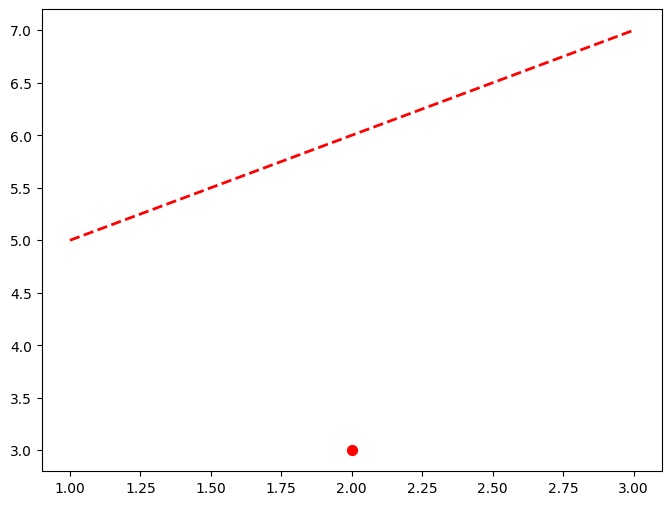

In [6]:

def decision_sample(x, w0, w1, w2, offset=0):
    return [x, (w0 + x * w1 - offset) / w2]
    


def decision(x):
    return [x, 2 + x]

def sample_point(x):
    return [x, -2 -x + 1]

plt.figure(figsize=(8, 6))


# Eine gute Entscheidungsgrenze (Decision Boundary):
# Linie zwischen den Punkten (4.5, 2) und (6.5, 4.5).
# plt.plot(line(1), line(5), color='blue', linestyle='--', linewidth=2, label='Entscheidungsgrenze')

p = decision_sample(2, 2, 1, 1, 1)
plt.scatter([p[0]], [p[1]], s=50, c='red', marker='o')

# plt.plot(decision(1), decision(5), color='blue', linestyle='--', linewidth=2, label='Entscheidungsgrenze')
plt.plot(decision_sample(1, 2, 1, 1), decision_sample(5, 2, 1, 1), color='red', linestyle='--', linewidth=2, label='Entscheidungsgrenze')

plt.show()



Begrenzungslinie und Punkt im positiven Bereich

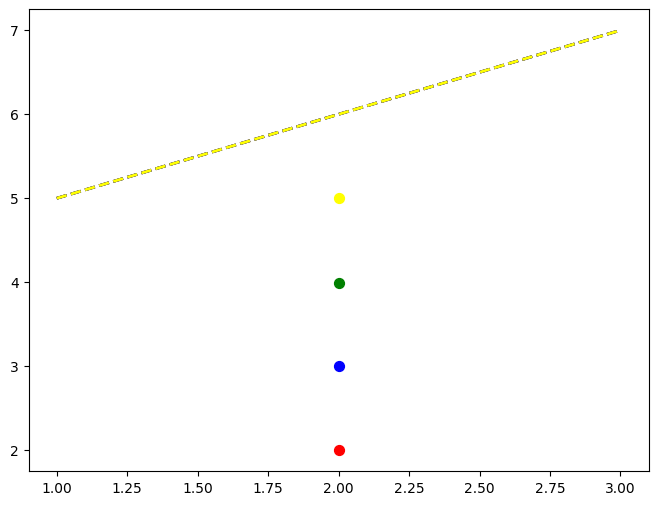

In [7]:
def decision_sample(x, w, offset=0):
    return [x, (w[0] + x * w[1] - offset) / w[2]]


plt.figure(figsize=(8, 6))


# Eine gute Entscheidungsgrenze (Decision Boundary):
# Linie zwischen den Punkten (4.5, 2) und (6.5, 4.5).
# plt.plot(line(1), line(5), color='blue', linestyle='--', linewidth=2, label='Entscheidungsgrenze')


w1 = [1, 0.5, 0.5]
p = decision_sample(2, w1, 1)
plt.scatter([p[0]], [p[1]], s=50, c='red', marker='o')
plt.plot(decision_sample(1, w1), decision_sample(5, w1), color='red', linestyle='--', linewidth=2, label='Entscheidungsgrenze')



w2 = [200, 100, 100]
p = decision_sample(2, w2, 1)
plt.scatter([p[0]], [p[1]], s=50, c='green', marker='o')
plt.plot(decision_sample(1, w2), decision_sample(5, w2), color='green', linestyle='--', linewidth=2, label='Entscheidungsgrenze')
# gleich mit der ersten

w3 = [2, 1, 1]
p = decision_sample(2, w3, 1)
plt.scatter([p[0]], [p[1]], s=50, c='blue', marker='o')
plt.plot(decision_sample(1, w3), decision_sample(5, w3), color='blue', linestyle='--', linewidth=2, label='Entscheidungsgrenze')

w4 = [-2, -1, -1]
p = decision_sample(2, w4, 1)
plt.scatter([p[0]], [p[1]], s=50, c='yellow', marker='o')
plt.plot(decision_sample(1, w4), decision_sample(5, w4), color='yellow', linestyle='--', linewidth=2, label='Entscheidungsgrenze')



plt.show()

# logic functions

## OR

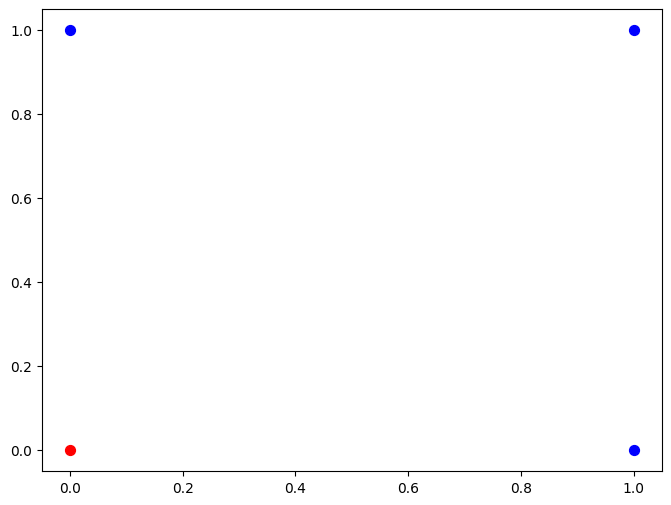

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter([0], [0], s=50, c='red', marker='o')
plt.scatter([0], [1], s=50, c='blue', marker='o')
plt.scatter([1], [0], s=50, c='blue', marker='o')
plt.scatter([1], [1], s=50, c='blue', marker='o')

plt.show()

## AND

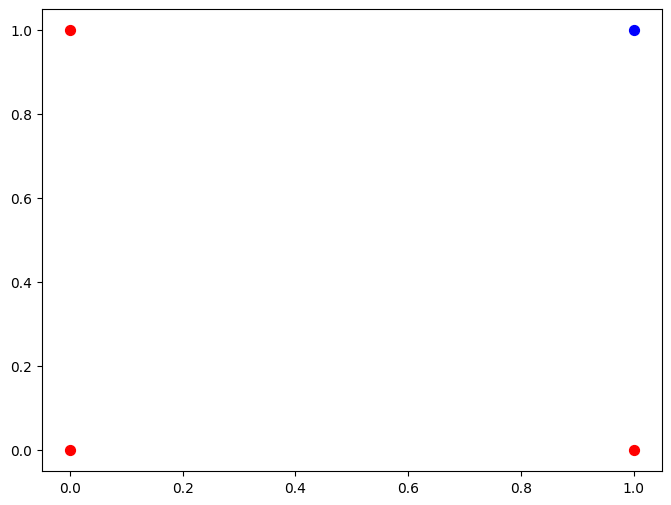

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter([0], [0], s=50, c='red', marker='o')
plt.scatter([0], [1], s=50, c='red', marker='o')
plt.scatter([1], [0], s=50, c='red', marker='o')
plt.scatter([1], [1], s=50, c='blue', marker='o')

plt.show()

## NOT

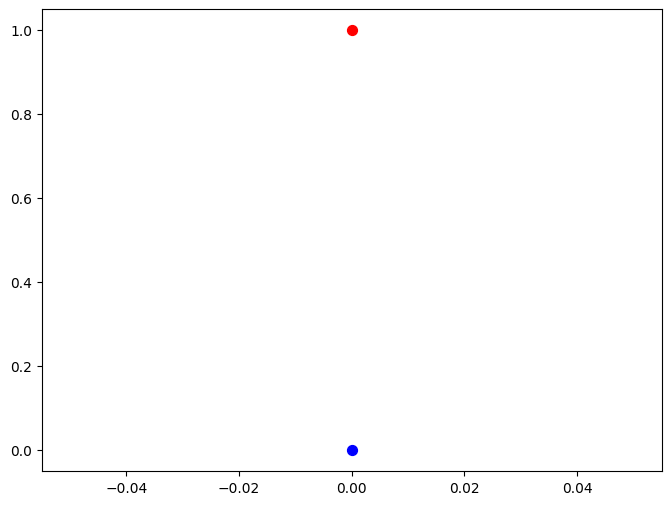

In [10]:
plt.figure(figsize=(8, 6))


# Eine gute Entscheidungsgrenze (Decision Boundary):
# Linie zwischen den Punkten (4.5, 2) und (6.5, 4.5).
# plt.plot(line(1), line(5), color='blue', linestyle='--', linewidth=2, label='Entscheidungsgrenze')


plt.scatter([0], [0], s=50, c='blue', marker='o')
plt.scatter([0], [1], s=50, c='red', marker='o')


plt.show()

## XOR

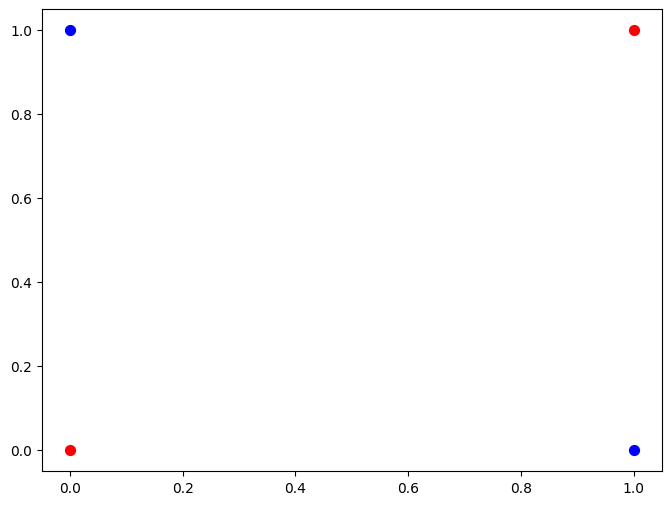

In [11]:
plt.figure(figsize=(8, 6))


# Eine gute Entscheidungsgrenze (Decision Boundary):
# Linie zwischen den Punkten (4.5, 2) und (6.5, 4.5).
# plt.plot(line(1), line(5), color='blue', linestyle='--', linewidth=2, label='Entscheidungsgrenze')


plt.scatter([0], [0], s=50, c='red', marker='o')
plt.scatter([0], [1], s=50, c='blue', marker='o')
plt.scatter([1], [0], s=50, c='blue', marker='o')
plt.scatter([1], [1], s=50, c='red', marker='o')


plt.show()

es kann keine trennlinie für ein XOR gezeichnet werden

# Aufgabe 3

In [12]:
using ScottPlot;
using ScottPlot.Plottables;


static (IEnumerable<TA>, IEnumerable<TB>) Unzip<TIn, TA, TB>(this IEnumerable<TIn> collection, Func<TIn, (TA, TB)> unzip) {
    var a = new List<TA>(); var b = new List<TB>();
    foreach (var (x,y) in collection.Select(unzip)) { a.Add(x); b.Add(y); }
    return (a, b);
}

static T Set<T>(this T target, Action<T> set) {
    set(target);
    return target;
}


## Random Points

In [13]:
public record struct Point(float X, float Y);

static IEnumerable<T> GeneratePoints<T>(this Random random, Func<Random, T> generator) {
    while (true) {
        yield return generator(random);
    }
}

static Point IntPoint(Random r, int min, int max) => 
    new Point(r.Next(min, max + 1), r.Next(min, max + 1));

static IEnumerable<Point> GenerateIntPoints(this Random random, int min = -1, int max = 1) => 
    GeneratePoints<Point>(random, r => IntPoint(r, min, max));


Random.Shared.GenerateIntPoints().Take(10)





index value 0 Point { X = 0, Y = 0 } X 0 Y 0 1 Point { X = 1, Y = 1 } X 1 Y 1 2 Point { X = 0, Y = 1 } X 0 Y 1 3 Point { X = 1, Y = 1 } X 1 Y 1 4 Point { X = 1, Y = 0 } X 1 Y 0 5 Point { X = 1, Y = -1 } X 1 Y -1 6 Point { X = 0, Y = 1 } X 0 Y 1 7 Point { X = 1, Y = 1 } X 1 Y 1 8 Point { X = -1, Y = -1 } X -1 Y -1 9 Point { X = 1, Y = 1 } X 1 Y 1


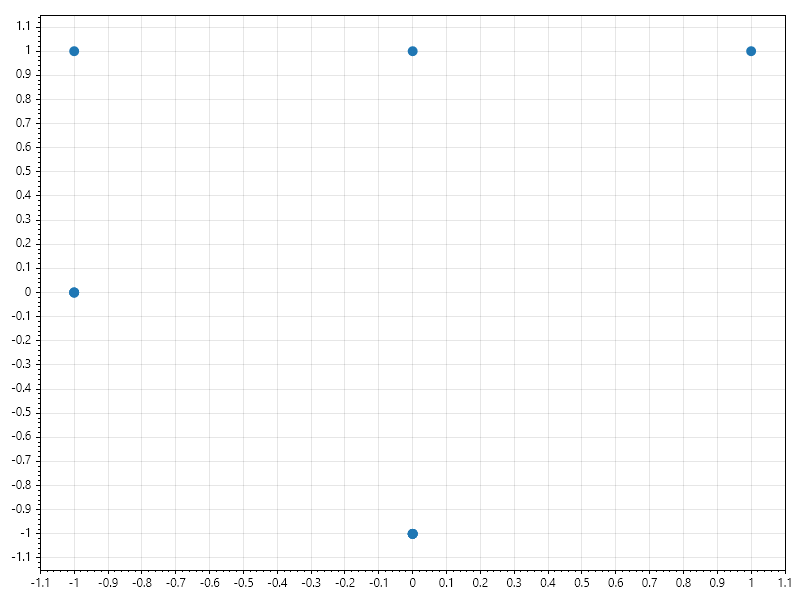

In [14]:

static Plot Draw(this Plot plot, IEnumerable<Point> points, float pointSize = 10) {
    var (x, y) = points.Unzip(x => ((double)x.X , (double)x.Y));

    plot.Add.Scatter(x.ToArray(), y.ToArray())
        .Set(s => s.LineWidth = 0)
        .Set(s => s.MarkerSize = pointSize);

    return plot;
}

static Plot Draw(this Plot plot, IEnumerable<Point> points, Color color, float pointSize = 10) {
    var (x, y) = points.Unzip(x => ((double)x.X , (double)x.Y));

    plot.Add.Scatter(x.ToArray(), y.ToArray(), color)
        .Set(s => s.LineWidth = 0)
        .Set(s => s.MarkerSize = pointSize);

    return plot;
}

var random = new Random();
ScottPlot.Plot plt = new();


// var (x, y) = random.GenerateIntPoints()
//     .Take(10)
//     .Unzip(x => ((double)x.X , (double)x.Y));

// plt.Add.Scatter(x.ToArray(), y.ToArray())
//     .Set(s => s.LineWidth = 0)
//     .Set(s => s.MarkerSize = 20);

plt.Draw(random.GenerateIntPoints().Take(10))




## Random Weight


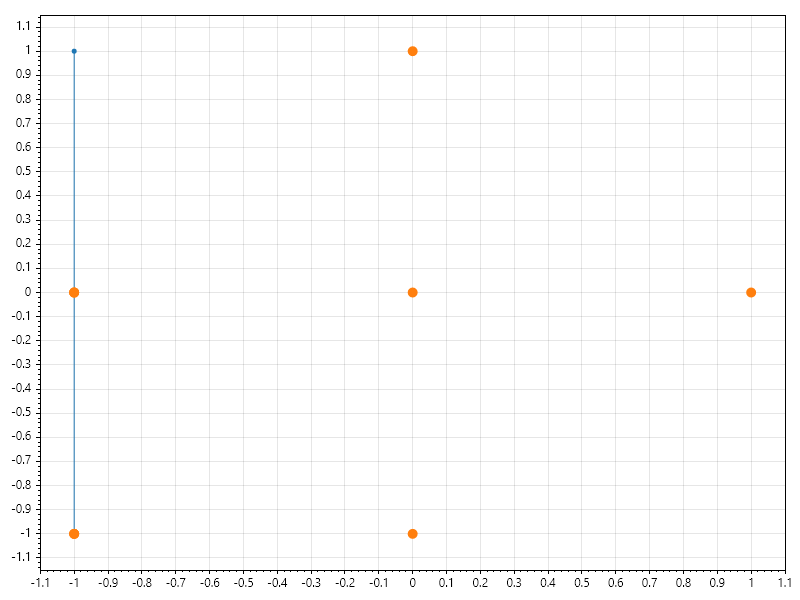

In [15]:
using System.Numerics;

public record struct Weight(float W1, float W2, float B)
{
    public static Weight FromPoints(Point A, Point B) {

        var m = new Point(B.X - A.X, B.Y - A.Y);
        if (m.X == 0 && m.Y == 0)
            throw new Exception("Points must be distinct");

        var normal = new Point(m.Y, -m.X);

        var bias = - (normal.X * A.X + normal.X * A.Y);

        return new Weight(normal.X, normal.Y, bias);
    }
}


static Weight RandomWeight(this Random random, int min = -1, int max = 1)
{
    var p = random.GenerateIntPoints(min, max).Take(2).ToArray();
    return Weight.FromPoints(p[0], p[1]);
}

// Boundary.FromPoints(new Point(-1, 0), new Point(-1, -1))


static (int[] X, int[] Y) WeightToPoints(this Weight b, int xMin = -1, int xMax = 1) 
{
    if (Math.Abs(b.W2) > 1e-12){
        int[] x = [xMin, xMax];
        int[] y = x.Select(x => (int)( - (b.W1 * x + b.B) / b.W2)).ToArray();
        return (x, y);
    }
    else if (Math.Abs(b.W1) > 1e-12) {
        var xConst = (int)(-b.B / b.W1);
        int[] x = [xConst, xConst];
        int[] y = [xMin, xMax];
        return (x, y);
    }
    else {
        throw new Exception("W1 and W2 are both 0");
    }
}

static Plot Draw(this Plot plot, Weight w) {
    var (x, y) = w.WeightToPoints();
    plot.Add.Scatter(x, y);

    return plot;
}

static Plot Draw(this Plot plot, Weight w, Color c) {
    var (x, y) = w.WeightToPoints();
    plot.Add.Scatter(x, y, c);

    return plot;
}


ScottPlot.Plot plt = new();

var r = new Random();
var b = r.RandomWeight();

plt.Draw(b).Draw(random.GenerateIntPoints().Take(10));

plt


## Predict
*which side of the Boundary the point is*

In [16]:
using System;
using MathNet.Numerics.LinearAlgebra;

// Primary API: w as Vector<double>, Xext as Matrix<double> (3 x m or m x 3)
public static int[] Predict(
    MathNet.Numerics.LinearAlgebra.Vector<double> w, 
    Matrix<double> Xext)
{
    if (w == null) throw new ArgumentNullException(nameof(w));
    if (w.Count != 3) throw new ArgumentException("w must have length 3", nameof(w));
    if (Xext == null) throw new ArgumentNullException(nameof(Xext));

    // If Xext was provided as m x 3, transpose to 3 x m
    if (Xext.RowCount != 3)
    {
        if (Xext.ColumnCount == 3)
            Xext = Xext.Transpose();
        else
            throw new ArgumentException("Xext must be 3xm or mx3", nameof(Xext));
    }

    // scores: 1 x m (row vector)
    var scores = w.ToRowMatrix() * Xext; // Matrix<double> 1 x m

    int m = scores.ColumnCount;
    var labels = new int[m];
    for (int j = 0; j < m; j++)
    {
        double s = scores[0, j];
        int p = Math.Sign(s);  // -1, 0, +1
        if (p == 0) p = 1;     // map zero to +1 to match Python code
        labels[j] = p;
    }
    return labels;
}

// Convenience: array inputs
public static int[] Predict(double[] wArr, double[,] Xarr)
{
    var w = MathNet.Numerics.LinearAlgebra.Vector<double>.Build.DenseOfArray(wArr);
    var X = MathNet.Numerics.LinearAlgebra.Matrix<double>.Build.DenseOfArray(Xarr);
    return Predict(w, X);
}

public static T[,] ToRectArray<T>(this T[][] jagged) {
    int rows = jagged.Length;
    int cols = rows > 0 ? jagged[0].Length : 0;
    T[,] rect = new T[rows, cols];
    for (int i = 0; i < rows; i++)
    for (int j = 0; j < cols; j++)
        rect[i, j] = jagged[i][j];
    return rect;
}

public static int[] Predict(Weight boundary, IEnumerable<Point> points)
{
    double[] b = [boundary.W1, boundary.W2, boundary.B];
    var p = points.Select(x => new double[] {x.X, x.Y, 1}).ToArray().ToRectArray();
    var w = MathNet.Numerics.LinearAlgebra.Vector<double>.Build.DenseOfArray(b);
    var X = MathNet.Numerics.LinearAlgebra.Matrix<double>.Build.DenseOfArray(p);
    return Predict(w, X);
}


## Test


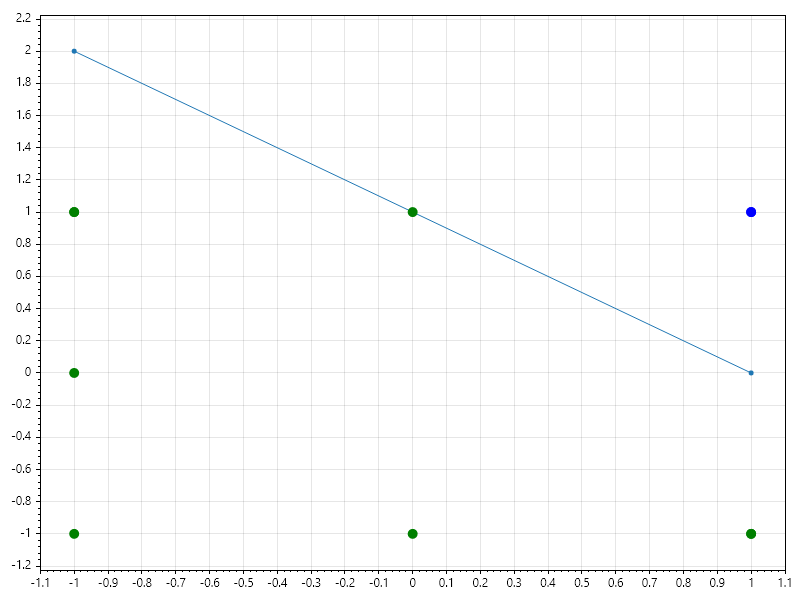

In [17]:
var r = new Random();

static Plot Draw(this Plot plot, IEnumerable<(Point, int)> labeledPoints) {
    
    var pos = labeledPoints.Where(x => x.Item2 >= 0).Select(x => x.Item1).ToArray();
    var neg = labeledPoints.Where(x => x.Item2 < 0).Select(x => x.Item1).ToArray();


    return plot
        .Draw(pos, Colors.Green)
        .Draw(neg, Colors.Blue);
}


var points = r.GenerateIntPoints().Take(10).ToArray();
var weight = r.RandomWeight();
var pred = Predict(weight, points);

var labeled = points.Zip(pred).ToArray();

var pos = labeled.Where(x => x.Item2 >= 0).Select(x => x.Item1).ToArray();
var neg = labeled.Where(x => x.Item2 < 0).Select(x => x.Item1).ToArray();


Plot plt = new();

plt.Draw(weight)
    .Draw(pos, Colors.Green)
    .Draw(neg, Colors.Blue);

plt


# Training

## Update weight

``` math
\mathbf{w}:=\mathbf{w}+\alpha ( y^{(i)} - h(\mathbf{x}^{(i)}) ) \mathbf{x}^{(i)}
```

In [45]:
Weight UpdateWeight(Weight w, Point p, int label, float learningRate) 
{
    return new Weight(
        (float)(w.W1 + learningRate * label * p.X),
        (float)(w.W2 + learningRate * label * p.Y),
        (float)(w.B  + learningRate * label * 1)
    );
}

// Point H(Point p) { // Whatever h is actually supposed to do
//     return p;
// }

// Weight UpdateWeight(Weight w, Point p, int label, float learningRate) 
// {
//     var h = H(p);

//     return new Weight(
//         (float)(w.W1 + learningRate * (label - h.X) * p.X),
//         (float)(w.W2 + learningRate * (label - h.Y) * p.Y),
//         (float)(w.B  + learningRate * (label - 1) * 1)
//     );
// }

## Init

Weight { W1 = 0.1, W2 = 0.1, B = -0.1 }
Weight { W1 = 0.1, W2 = 0.1, B = 0 }
Finished after 3 iterations



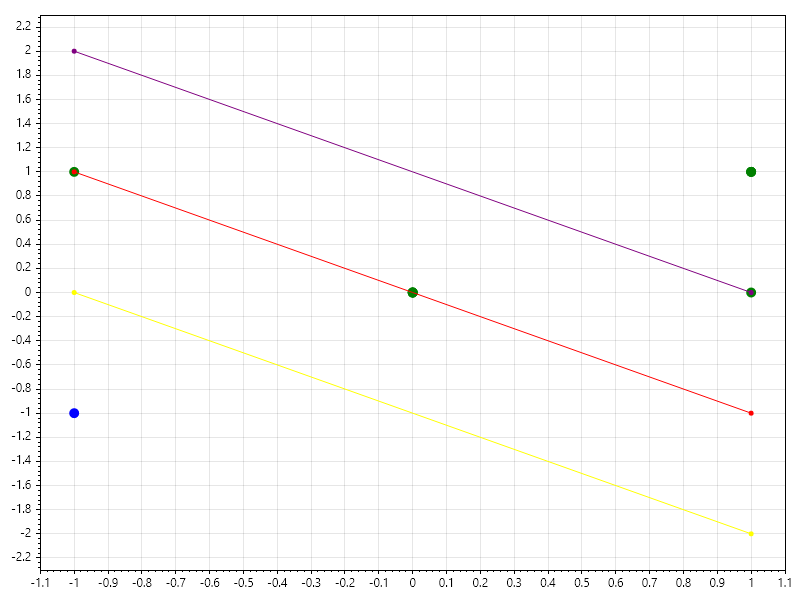

In [49]:
Random r = new();
int min = -1;
int max =  1;
int pointCount = 10;

Weight w = new(0, 0, 0); // perceptron / trainings vector
float learningRate = 0.1f;
int iterationsCount = 10;


var points = r.GenerateIntPoints(min, max).Take(pointCount).ToArray();
var bound = r.RandomWeight(); // Random boundary for assigning a label
var labels = Predict(bound, points);

var labeledPoints = points.Zip(labels).ToArray();

List<int> numberOfMisses = [];
List<(Weight, (Point, int))> checks = [];


for (int i = 0; i < iterationsCount; i++) {

    var preds = Predict(w, points);
    var mismatched = labeledPoints // Get all points where the labels don't match
        .Zip(preds)
        .Where(x => x.Item1.Item2 != x.Item2)
        .Select(x => x.Item1)
        .ToArray();

    numberOfMisses.Add(mismatched.Length);

    if (mismatched.Length == 0)
    {
        Console.WriteLine($"Finished after {i+1} iterations");
        break;
    }

    var point = mismatched[r.Next(mismatched.Length)];

    checks.Add((w, point));
    w = UpdateWeight(w, point.Item1, point.Item2, learningRate);
    Console.WriteLine(w);
}

// checks
var plt = new Plot()
    .Draw(labeledPoints)
    .Draw(bound, Colors.Yellow)
    .Draw(w, Colors.Red);

foreach (var (w, _) in checks) {
    if (w.W1 != 0 || w.W2 != 0)
        plt.Draw(w, Colors.Purple);
}

// points
plt

# Post mortem

Jede Person beschreibt in der ILIAS-Abgabe individuell(!) die Bearbeitung des jeweiligen Aufgabenblattes
zurückblickend mit ca. 200 bis 400 Wörtern. Gehen Sie dabei aussagekräftig und nachvollziehbar auf folgende Punkte ein: 
 (a) Zusammenfassung: Was wurde gemacht? 
 (b) Implementierungsdetails: Kurze Beschreibung besonders interessanter Aspekte der Umsetzung. 
 (c) Was war der schwierigste Teil bei der Bearbeitung? Wie haben Sie dieses Problem gelöst? 
 (d) Was haben Sie gelernt oder (besser) verstanden? 
 (e) Team: Mit wem haben Sie zusammengearbeitet? 
 (f) Link zum Repo mit der Lösung 



 * a: Für die erste Aufgabe habe ich gegebenen Grenzen mithilfe von matplotlib gezeichnet. Auch die zweite Aufgabe habe ich in einen Plot gezeichnet. Dadurch wird recht offensichtlich, wie die Entscheidungsgrenze für die Logikgatter aussehen müsste. Außerdem veranschaulicht das, warum ein XOR nicht mit einem solchen Perceptron implementiert werden kann. Um die letzte Aufgabe zu implementieren, habe ich mich an das gegebene Jupyter Notebook gehalten.
 * b: Nach der Implementation in Python habe ich das Perceptron noch einmal in C# implementiert.
 * c: Ich hatte dieser Woche einige Schwierigkeiten, die Aufgaben zu erledigen. Ich bin mir nicht sicher, woran genau das liegt, da das grundsätzliche Konzept eines Perceptron eigentlich recht einfach ist. Mein größtes Problem war dabei glaube ich das Python notebook. Alleine klare return Typen an den Funktionen hätten Warscheineich schon deutlich weiter geholfen, zu erklären, was die einzelnen Funktionen machen sollen. Aus diesem Grund habe ich das Perceptron danach auch noch einmal in C# implementiert. Was den Code definitive klarer gemacht hat.
 * d:
 * e: -
 * f: https://github.com/co1inco/IFM_Programieren3/tree/master/KI/7